# 06 Shipment Prioritization

**The question this notebook answers:** we cannot chase every order. Which ones should the team work on first?

**The idea in one minute.** Notebook 05 gave every order a chance of being late (a number from 0 to 1). A late order that is worth a lot of money hurts more than a late order that is worth little. So we multiply the two:

**priority = chance of being late × Sales**

Example: a $900 order with a 60% chance of being late has priority 540. A $40 order that is 99% sure to be late has priority 40. The first one goes first.

**What you will see in this notebook**

1. The data and the model we use.
2. A check that the chances can be trusted.
3. A fair contest: Heads Up against simpler ways of ordering the work.
4. A simple rule that turns out to be a strong rival.
5. A dial that trades money against accuracy.
6. Three action tiers for the app.

**Two numbers we use to judge a work queue.** Say we only have time to review the top 10% of orders.

- **Revenue reached:** of all the money in orders that really were late, how much sits inside our top 10%?
- **Precision:** of the orders we reviewed, how many were really late?

In [1]:
import json, warnings
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
warnings.filterwarnings('ignore')

SEED = 42
KS = (0.05, 0.10, 0.20, 0.30)      # review budgets we test
N_BOOT = 300                        # bootstrap repeats
DATA = Path('../data/processed'); MODELS = Path('../models')
thr_file = DATA / 'chosen_threshold.json'
THRESHOLD = json.load(open(thr_file))['threshold'] if thr_file.exists() else 0.38
print('Risk threshold from notebook 05:', THRESHOLD)

# one colour per idea, used in every chart below
COL = {'Random order':'#8c8c8c', 'Sales only':'#1b9e8a', 'Simple rule (mode)':'#c8691a',
       'Simple rule (mode and noon)':'#c8691a', 'Risk only':'#8a63d2',
       'Heads Up (risk x Sales)':'#2a6fdb', 'Oracle (perfect)':'#222222'}
plt.rcParams.update({'axes.spines.top':False, 'axes.spines.right':False, 'axes.grid':True,
                     'grid.alpha':0.25, 'figure.dpi':110, 'axes.titlesize':11, 'axes.titleweight':'bold'})

Risk threshold from notebook 05: 0.38


## 1. Load the data and the model
The raw files hold the real Sales amounts. The model ready files hold the model inputs. Both files have the same rows in the same order, and the code checks that.

In [2]:
def load_split(name):
    raw = pd.read_csv(DATA/f'{name}.csv')
    mr  = pd.read_csv(DATA/f'model_ready_{name}.csv')
    b = mr.select_dtypes(include='bool').columns; mr[b] = mr[b].astype(int)
    X = mr.drop(columns='Late_delivery_risk'); y = mr['Late_delivery_risk'].values
    assert len(raw) == len(mr) and (raw['Late_delivery_risk'].values == y).all(), f'{name}: rows do not line up'
    return raw, X, y

raw_tr, X_tr, y_tr = load_split('train')
raw_va, X_va, y_va = load_split('val')
raw_te, X_te, y_te = load_split('test')

pkl = MODELS / 'random_forest_tuned.pkl'
if pkl.exists():
    rf = joblib.load(pkl); print('Loaded', pkl.name)
else:
    from sklearn.ensemble import RandomForestClassifier
    params = json.load(open(DATA/'optuna_rf_best_params.json'))
    rf = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1).fit(X_tr, y_tr); print('Trained the Random Forest from the saved best settings')

p_va = rf.predict_proba(X_va)[:,1]; p_te = rf.predict_proba(X_te)[:,1]
print(f'validation: {len(y_va):,} orders, {y_va.mean():.1%} late, ROC AUC {roc_auc_score(y_va,p_va):.3f}')
print(f'test:       {len(y_te):,} orders, {y_te.mean():.1%} late, ROC AUC {roc_auc_score(y_te,p_te):.3f}')

Loaded random_forest_tuned.pkl
validation: 7,890 orders, 54.2% late, ROC AUC 0.762
test:       11,836 orders, 55.1% late, ROC AUC 0.752


### What does lateness depend on?
One chart explains most of this notebook. Shipping Mode alone separates late orders from on time orders very well. Same Day orders placed before noon are never late. Same Day orders placed at noon or later are almost always late.

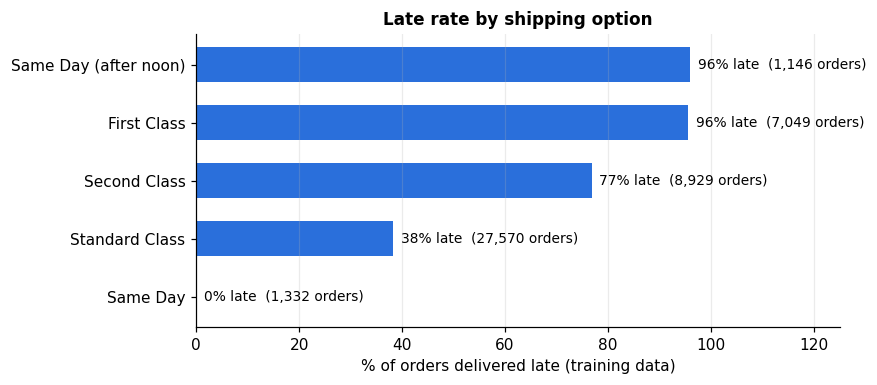

In [3]:
def hour(df): return pd.to_datetime(df['order date (DateOrders)']).dt.hour
def rule_key(df):
    pm = (df['Shipping Mode'] == 'Same Day') & (hour(df) >= 12)
    return df['Shipping Mode'].astype(str) + np.where(pm, ' (after noon)', '')
raw_tr['rk'] = rule_key(raw_tr)
g = raw_tr.groupby('rk')['Late_delivery_risk'].agg(['mean','size']).sort_values('mean')
rate_mode = raw_tr.groupby('Shipping Mode')['Late_delivery_risk'].mean()
rate_key  = g['mean']

fig, ax = plt.subplots(figsize=(8,3.6))
bars = ax.barh(g.index, g['mean']*100, color='#2a6fdb', height=0.6)
for b,(m,n) in zip(bars, zip(g['mean'], g['size'])):
    ax.text(b.get_width()+1.5, b.get_y()+b.get_height()/2, f'{m:.0%} late  ({n:,} orders)', va='center', fontsize=9)
ax.set_xlim(0,125); ax.set_xlabel('% of orders delivered late (training data)'); ax.set_title('Late rate by shipping option'); ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

### Order value changes over time
The data is split by date: train is oldest, test is newest. The chart below shows that orders in the test period are smaller. We come back to this at the end.

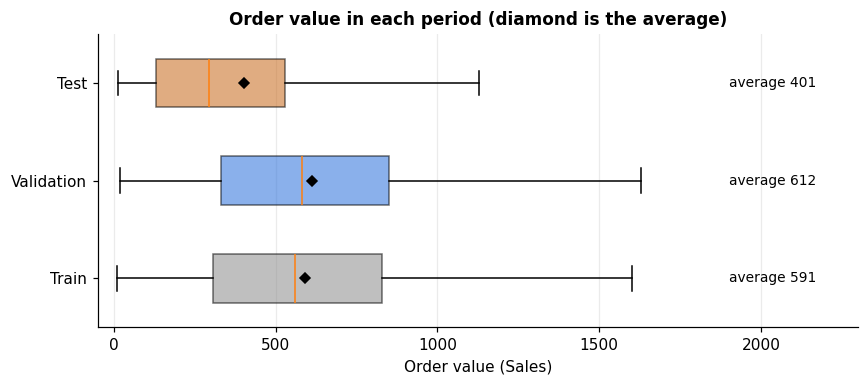

In [4]:
fig, ax = plt.subplots(figsize=(8,3.6))
parts = [(raw_tr,'Train','#8c8c8c'), (raw_va,'Validation','#2a6fdb'), (raw_te,'Test','#c8691a')]
bp = ax.boxplot([d.Sales for d,_,_ in parts], labels=[n for _,n,_ in parts], vert=False, patch_artist=True, showfliers=False, widths=0.5)
for patch,(_,_,c) in zip(bp['boxes'], parts): patch.set_facecolor(c); patch.set_alpha(0.55)
for i,(d,n,c) in enumerate(parts, start=1):
    ax.plot(d.Sales.mean(), i, 'D', color='black', ms=5); ax.text(1900, i, f'average {d.Sales.mean():,.0f}', va='center', fontsize=9)
ax.set_xlim(-50, 2300); ax.set_xlabel('Order value (Sales)'); ax.set_title('Order value in each period (diamond is the average)'); ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

## 2. Priority score, shown with a small example

Three made up orders. Look at which one wins on priority, and which one would win if we only looked at risk, or only at money.

,Order,Chance late,Sales,Priority
0,A: big and likely late,0.60,900,540.0
1,B: small but almost sure,0.99,40,39.6
2,C: big but unlikely,0.15,1000,150.0


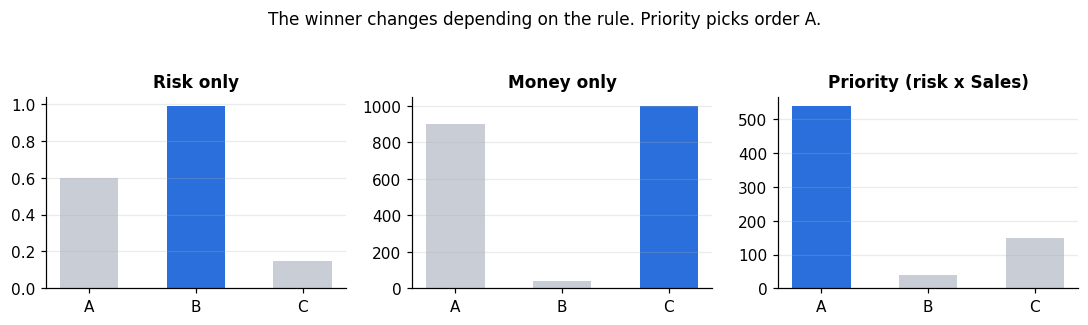

In [5]:
ex = pd.DataFrame({'Order':['A: big and likely late','B: small but almost sure','C: big but unlikely'],
                   'Chance late':[0.60, 0.99, 0.15], 'Sales':[900, 40, 1000]})
ex['Priority'] = ex['Chance late'] * ex['Sales']
display(ex)

fig, axs = plt.subplots(1,3, figsize=(10,2.8))
for ax,col,t in zip(axs, ['Chance late','Sales','Priority'], ['Risk only','Money only','Priority (risk x Sales)']):
    vals = ex[col].values; best = vals.argmax()
    ax.bar(['A','B','C'], vals, color=['#2a6fdb' if i==best else '#c9ced6' for i in range(3)], width=0.55)
    ax.set_title(t); ax.grid(axis='x', alpha=0)
fig.suptitle('The winner changes depending on the rule. Priority picks order A.', y=1.04, fontsize=11)
plt.tight_layout(); plt.show()

## 3. Can we trust the chances?
Before we multiply a chance by money, the chance must be honest. If the model says 80%, about 80 of 100 such orders should really be late. In the left chart, dots near the dashed line mean the model is honest. Our dots are close to the line. The one weak spot is the lowest risk group: the model says about 18% but 27% were really late.

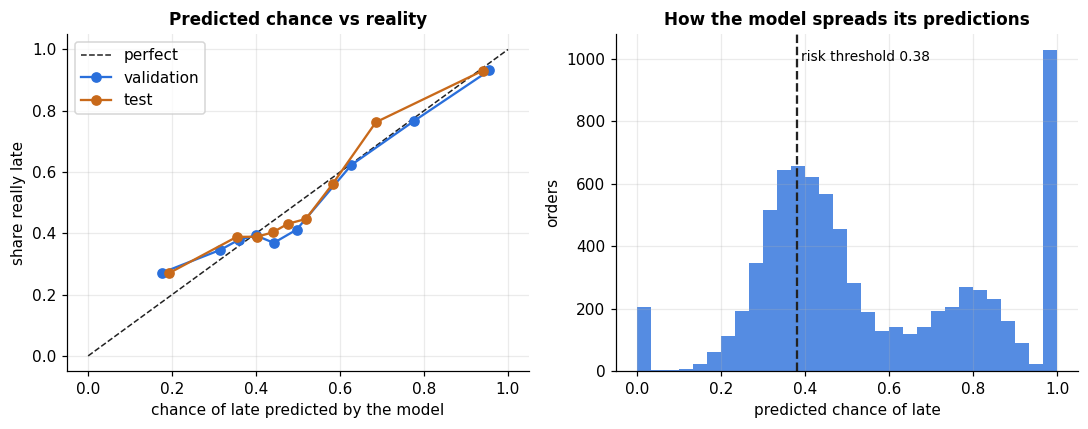

In [6]:
def calib(p, y):
    q = pd.qcut(p, 10, duplicates='drop')
    return pd.DataFrame({'p':p,'y':y}).groupby(q, observed=True).agg(predicted=('p','mean'), actual=('y','mean'), n=('y','size'))
g_va, g_te = calib(p_va,y_va), calib(p_te,y_te)
base = y_tr.mean()

fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].plot([0,1],[0,1],'--',color='#222222',lw=1,label='perfect')
axs[0].plot(g_va.predicted, g_va.actual, 'o-', color='#2a6fdb', label='validation')
axs[0].plot(g_te.predicted, g_te.actual, 'o-', color='#c8691a', label='test')
axs[0].set_xlabel('chance of late predicted by the model'); axs[0].set_ylabel('share really late'); axs[0].set_title('Predicted chance vs reality'); axs[0].legend()
axs[1].hist(p_va, bins=30, color='#2a6fdb', alpha=0.8, label='validation'); axs[1].axvline(THRESHOLD, color='#222222', ls='--')
axs[1].text(THRESHOLD+0.01, axs[1].get_ylim()[1]*0.92, f'risk threshold {THRESHOLD}', fontsize=9)
axs[1].set_xlabel('predicted chance of late'); axs[1].set_ylabel('orders'); axs[1].set_title('How the model spreads its predictions')
plt.tight_layout(); plt.show()

## 4. The contest
We test Heads Up against simpler ways of ordering the work. Every method gets the same effort, for example the top 10% of orders.

- **Random order:** pick orders by luck.
- **Sales only:** biggest orders first.
- **Risk only:** most likely late first.
- **Simple rule:** look up the late rate of the shipping option. No machine learning.
- **Oracle:** a perfect helper that already knows which orders are late. Nobody can do better, so it is the ceiling.

In [7]:
def make_scores(raw, p, y):
    S = raw['Sales'].values; rng = np.random.default_rng(SEED)
    return {
      'Random order':                rng.random(len(y)),
      'Sales only':                  S,
      'Simple rule (mode)':          raw['Shipping Mode'].map(rate_mode).values * S,
      'Simple rule (mode and noon)': rule_key(raw).map(rate_key).values * S,
      'Risk only':                   p + 1e-12*S,
      'Heads Up (risk x Sales)':     p * S,
      'Oracle (perfect)':            y * S + 1e-9*S,
    }
ORDER = list(make_scores(raw_va, p_va, y_va).keys())

def value_precision(sc, S, y, k):
    n = int(len(y)*k); idx = np.argsort(-sc, kind='stable')[:n]
    return (S*y)[idx].sum()/(S*y).sum(), y[idx].mean()

def evaluate(raw, p, y):
    S = raw['Sales'].values; rows = []
    for sn, sc in make_scores(raw,p,y).items():
        for k in KS:
            v, pr = value_precision(sc, S, y, k); rows.append(dict(scheme=sn, K=f'{k:.0%}', revenue_reached=v, precision=pr))
    return pd.DataFrame(rows)

ev_va, ev_te = evaluate(raw_va,p_va,y_va), evaluate(raw_te,p_te,y_te)
def show(ev, col):
    t = ev.pivot(index='scheme', columns='K', values=col).loc[ORDER]; return t[[f'{k:.0%}' for k in KS]].round(3)
print('VALIDATION, revenue reached (higher is better)'); display(show(ev_va,'revenue_reached'))
print('VALIDATION, precision'); display(show(ev_va,'precision'))

VALIDATION, revenue reached (higher is better)


K,5%,10%,20%,30%
scheme,,,,
Random order,0.054,0.106,0.201,0.301
Sales only,0.109,0.203,0.364,0.508
Simple rule (mode),0.152,0.266,0.433,0.566
Simple rule (mode and noon),0.155,0.273,0.447,0.583
Risk only,0.146,0.220,0.343,0.482
Heads Up (risk x Sales),0.158,0.272,0.444,0.574
Oracle (perfect),0.193,0.347,0.596,0.783


VALIDATION, precision


K,5%,10%,20%,30%
scheme,,,,
Random order,0.579,0.561,0.541,0.545
Sales only,0.523,0.530,0.529,0.538
Simple rule (mode),0.873,0.849,0.773,0.700
Simple rule (mode and noon),0.878,0.866,0.807,0.732
Risk only,1.000,1.000,0.932,0.877
Heads Up (risk x Sales),0.911,0.863,0.786,0.725
Oracle (perfect),1.000,1.000,1.000,1.000


### Chart: how much late revenue do we reach as we review more orders?
Each line is a method. The higher the line, the more at risk money is reached for the same effort. The dashed black line is the oracle ceiling.

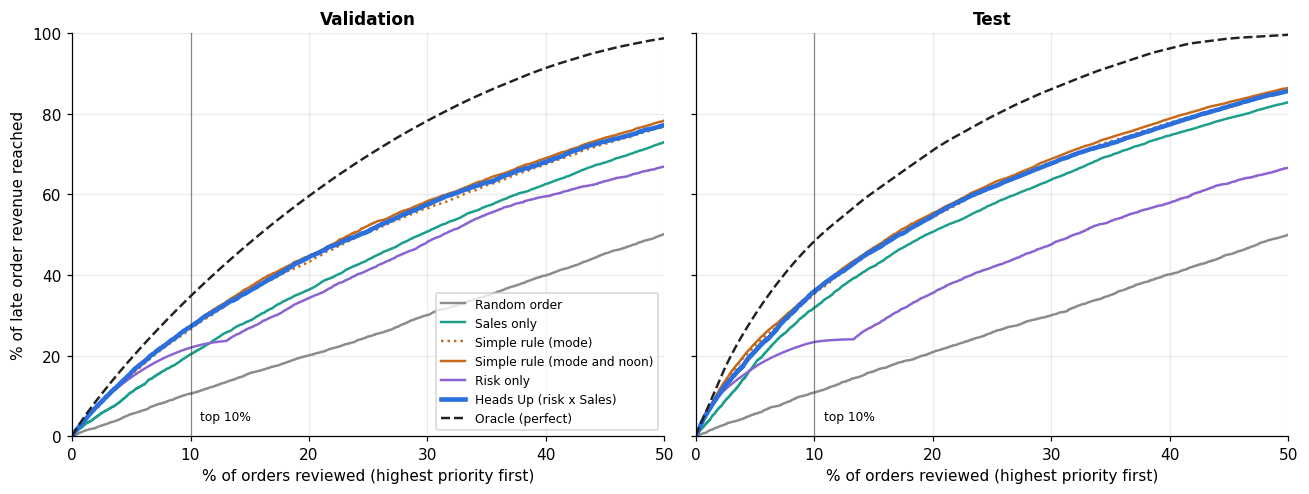

In [8]:
def gain_curve(sc, S, y):
    idx = np.argsort(-sc, kind='stable'); cum = np.cumsum((S*y)[idx]) / (S*y).sum()
    return np.arange(1, len(y)+1)/len(y)*100, cum*100

fig, axs = plt.subplots(1,2, figsize=(12,4.6), sharey=True)
for ax,(nm,raw,p,y) in zip(axs, (('Validation',raw_va,p_va,y_va),('Test',raw_te,p_te,y_te))):
    S = raw['Sales'].values
    for sn, sc in make_scores(raw,p,y).items():
        x,c = gain_curve(sc,S,y)
        ls = '--' if 'Oracle' in sn else (':' if sn=='Simple rule (mode)' else '-')
        ax.plot(x, c, ls, color=COL[sn], lw=3 if 'Heads Up' in sn else 1.6, label=sn)
    ax.axvline(10, color='#222222', lw=0.8, alpha=0.5); ax.text(10.8, 4, 'top 10%', fontsize=8)
    ax.set_xlim(0,50); ax.set_ylim(0,100); ax.set_xlabel('% of orders reviewed (highest priority first)'); ax.set_title(nm)
axs[0].set_ylabel('% of late order revenue reached'); axs[0].legend(fontsize=8, loc='lower right')
plt.tight_layout(); plt.show()

### Chart: the top 10% side by side
Left: money reached. Right: how many reviewed orders were really late.

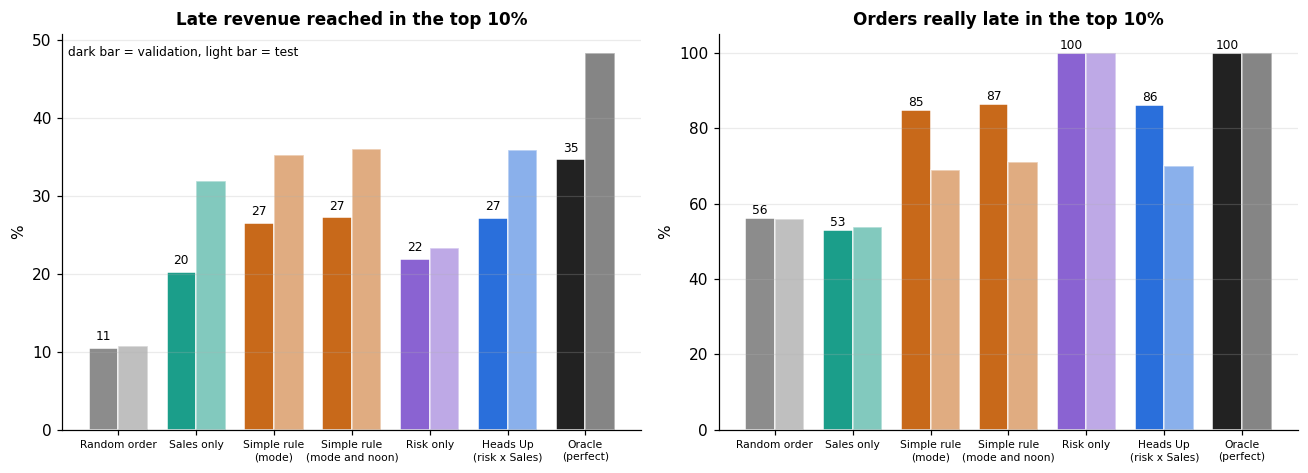

In [9]:
fig, axs = plt.subplots(1,2, figsize=(12,4.4))
w = 0.38; xs = np.arange(len(ORDER))
for ax, col, title in zip(axs, ['revenue_reached','precision'], ['Late revenue reached in the top 10%','Orders really late in the top 10%']):
    for j,(nm,ev,off,alpha) in enumerate((('Validation',ev_va,-w/2,1.0),('Test',ev_te,w/2,0.55))):
        d = ev[ev.K=='10%'].set_index('scheme').loc[ORDER, col]*100
        ax.bar(xs+off, d.values, w, color=[COL[s] for s in ORDER], alpha=alpha, edgecolor='white', label=nm)
        if nm=='Validation':
            for x,v in zip(xs+off, d.values): ax.text(x, v+1, f'{v:.0f}', ha='center', fontsize=8)
    ax.set_xticks(xs); ax.set_xticklabels([s.replace(' (','\n(') for s in ORDER], fontsize=7, rotation=0)
    ax.set_ylabel('%'); ax.set_title(title); ax.grid(axis='x', alpha=0)
axs[0].text(0.01, 0.97, 'dark bar = validation, light bar = test', transform=axs[0].transAxes, fontsize=8, va='top')
plt.tight_layout(); plt.show()

In [10]:
print('TEST, revenue reached'); display(show(ev_te,'revenue_reached'))
print('TEST, precision'); display(show(ev_te,'precision'))
oracle = ev_va[(ev_va.K=='10%') & (ev_va.scheme=='Oracle (perfect)')].revenue_reached.iloc[0]
hu = ev_va[(ev_va.K=='10%') & (ev_va.scheme=='Heads Up (risk x Sales)')].revenue_reached.iloc[0]
print(f'At the top 10% on validation, Heads Up reaches {hu/oracle:.0%} of what a perfect oracle could reach.')

TEST, revenue reached


K,5%,10%,20%,30%
scheme,,,,
Random order,0.056,0.108,0.208,0.300
Sales only,0.180,0.319,0.507,0.636
Simple rule (mode),0.225,0.353,0.543,0.678
Simple rule (mode and noon),0.231,0.360,0.554,0.688
Risk only,0.172,0.234,0.355,0.476
Heads Up (risk x Sales),0.211,0.359,0.546,0.677
Oracle (perfect),0.302,0.484,0.709,0.861


TEST, precision


K,5%,10%,20%,30%
scheme,,,,
Random order,0.569,0.560,0.553,0.548
Sales only,0.526,0.539,0.542,0.548
Simple rule (mode),0.849,0.691,0.680,0.668
Simple rule (mode and noon),0.865,0.710,0.703,0.683
Risk only,1.000,1.000,0.931,0.875
Heads Up (risk x Sales),0.751,0.700,0.694,0.668
Oracle (perfect),1.000,1.000,1.000,1.000


At the top 10% on validation, Heads Up reaches 78% of what a perfect oracle could reach.


### Chart: where does the top 10% queue come from?
Each dot is a validation order. Risk only picks the right edge, Sales only picks the top edge. Heads Up picks the upper right corner, where both are high.

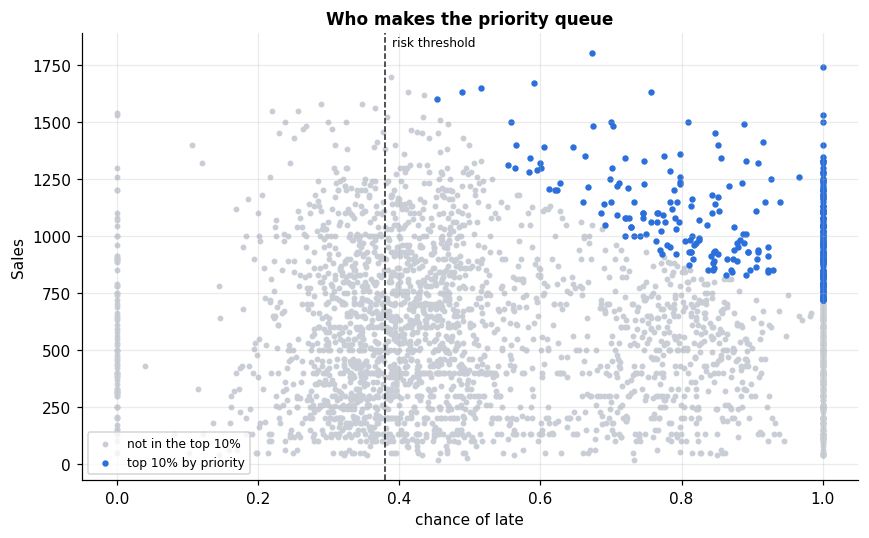

In [11]:
rs = np.random.default_rng(1).choice(len(y_va), 3000, replace=False)
S_va = raw_va.Sales.values; pr_va = p_va * S_va
cut = np.quantile(pr_va, 0.90)
inq = pr_va >= cut
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(p_va[rs][~inq[rs]], S_va[rs][~inq[rs]], s=8, color='#c9ced6', label='not in the top 10%')
ax.scatter(p_va[rs][inq[rs]],  S_va[rs][inq[rs]],  s=10, color='#2a6fdb', label='top 10% by priority')
ax.axvline(THRESHOLD, color='#222222', ls='--', lw=1); ax.text(THRESHOLD+0.01, ax.get_ylim()[1]*0.97, 'risk threshold', fontsize=8)
ax.set_xlabel('chance of late'); ax.set_ylabel('Sales'); ax.set_title('Who makes the priority queue'); ax.legend(loc='lower left', fontsize=8)
plt.tight_layout(); plt.show()

## 5. Is the model better than a simple rule?
This is the fair question. A simple rule says: "First Class is almost always late, Standard Class is often fine, Same Day after noon is late." It takes two minutes to build.

The chart below compares the model with that rule in the top 10% queue. The bars show how much late revenue each one reaches.

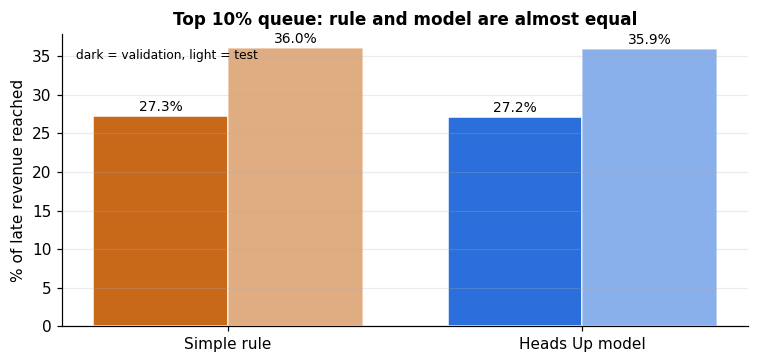

In [12]:
r_model = ev_va[(ev_va.K=='10%')].set_index('scheme')
names = ['Simple rule (mode and noon)', 'Heads Up (risk x Sales)']
fig, ax = plt.subplots(figsize=(7,3.4))
for j,(nm,ev,al) in enumerate((('Validation',ev_va,1.0),('Test',ev_te,0.55))):
    v = ev[ev.K=='10%'].set_index('scheme').loc[names,'revenue_reached']*100
    ax.bar(np.arange(2)+(j-0.5)*0.38, v.values, 0.38, color=[COL[n] for n in names], alpha=al, edgecolor='white')
    for x,val in zip(np.arange(2)+(j-0.5)*0.38, v.values): ax.text(x, val+0.6, f'{val:.1f}%', ha='center', fontsize=9)
ax.set_xticks([0,1]); ax.set_xticklabels(['Simple rule', 'Heads Up model']); ax.set_ylabel('% of late revenue reached')
ax.set_title('Top 10% queue: rule and model are almost equal'); ax.text(0.02, 0.95, 'dark = validation, light = test', transform=ax.transAxes, fontsize=8, va='top'); ax.grid(axis='x', alpha=0)
plt.tight_layout(); plt.show()

**Could this tiny gap be luck?** We repeated the comparison 300 times on random re drawn samples of the orders. Each repeat gives one gap. The black line is zero, which means a tie. The blue bars sit on both sides of zero, so there is no clear winner.

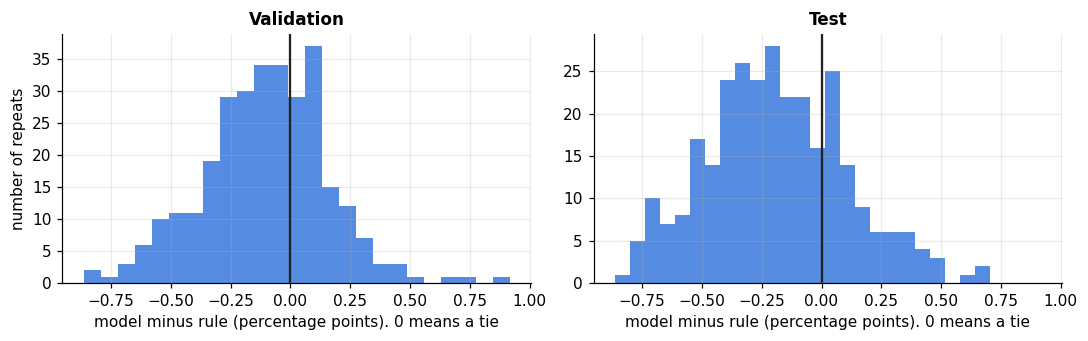

In [13]:
def boot_diff(raw, p, y, k=0.10, n_boot=N_BOOT):
    S = raw['Sales'].values; model = p*S; r2 = rule_key(raw).map(rate_key).values*S
    rng = np.random.default_rng(0); d = []
    for _ in range(n_boot):
        i = rng.integers(0, len(y), len(y))
        d.append(value_precision(model[i],S[i],y[i],k)[0] - value_precision(r2[i],S[i],y[i],k)[0])
    return np.array(d)

fig, axs = plt.subplots(1,2, figsize=(10,3.2), sharex=True)
for ax,(nm,raw,p,y) in zip(axs, (('Validation',raw_va,p_va,y_va),('Test',raw_te,p_te,y_te))):
    d = boot_diff(raw,p,y)*100
    ax.hist(d, bins=25, color='#2a6fdb', alpha=0.8); ax.axvline(0, color='#222222', lw=1.5)
    ax.set_title(nm); ax.set_xlabel('model minus rule (percentage points). 0 means a tie')
axs[0].set_ylabel('number of repeats')
plt.tight_layout(); plt.show()

**What this means.** For ordering the top 10%, the model and the simple rule tie. We say this openly in the report. The model still adds value in two ways: it gives a separate chance for every order, and SHAP explains why each order is risky. A simple rule cannot do that.

## 6. A dial: how much should risk count compared with money?
So far the score is chance × Sales. We can turn a dial to give more weight to risk or more weight to money. We tried six settings.

- **Money first:** the biggest orders go first.
- **Balanced:** chance × Sales. This is our choice.
- **Risk first:** the most likely late orders go first.

The chart shows the trade. Going to the right gives a cleaner queue (more orders really late), but it reaches less money. Balanced reaches the most money.

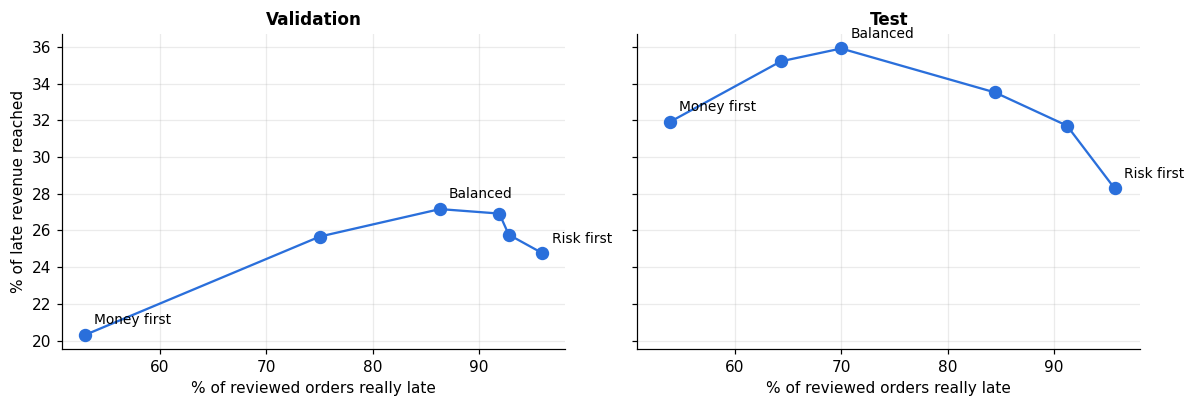

In [14]:
dial = {0:'Money first', 0.5:'', 1:'Balanced', 2:'', 3:'', 5:'Risk first'}
rows = []
for nm,raw,y,p in (('Validation',raw_va,y_va,p_va),('Test',raw_te,y_te,p_te)):
    S = raw['Sales'].values
    for a in dial:
        sc = (p**a)*S if a > 0 else S
        v, pr = value_precision(sc, S, y, 0.10); rows.append(dict(split=nm, alpha=a, revenue_reached=v, precision=pr))
alpha_tbl = pd.DataFrame(rows)

fig, axs = plt.subplots(1,2, figsize=(11,3.8), sharey=True, sharex=True)
for ax,nm in zip(axs, ['Validation','Test']):
    d = alpha_tbl[alpha_tbl.split==nm]
    ax.plot(d.precision*100, d.revenue_reached*100, '-', color='#2a6fdb', lw=1.5)
    ax.scatter(d.precision*100, d.revenue_reached*100, s=60, color='#2a6fdb', zorder=3)
    for _,r in d.iterrows():
        if dial[r.alpha]: ax.annotate(dial[r.alpha], (r.precision*100, r.revenue_reached*100), textcoords='offset points', xytext=(6,7), fontsize=9)
    ax.set_title(nm); ax.set_xlabel('% of reviewed orders really late')
axs[0].set_ylabel('% of late revenue reached')
plt.tight_layout(); plt.show()

## 7. Three action tiers
A long list of scores is hard to act on. So we sort orders into three groups.

- **Critical:** the top 10% by priority score. Act today.
- **High:** the next 20%. Act this week.
- **Standard:** everything else. Normal handling.

We set the cut points on the validation data. Then we used the same cut points on the test data. The charts show that the groups behave as we want: Critical orders are the most often late.

Validation


,Orders,Share really late,Average order value,Share of all orders,Share of late revenue
tier,,,,,
1 Critical,789,0.86,1054.56,0.10,0.27
2 High,1487,0.67,818.61,0.19,0.28
3 Standard,5614,0.46,494.93,0.71,0.44


Test


,Orders,Share really late,Average order value,Share of all orders,Share of late revenue
tier,,,,,
1 Critical,710,0.73,1282.42,0.06,0.24
2 High,1082,0.70,843.56,0.09,0.22
3 Standard,10044,0.52,291.54,0.85,0.54


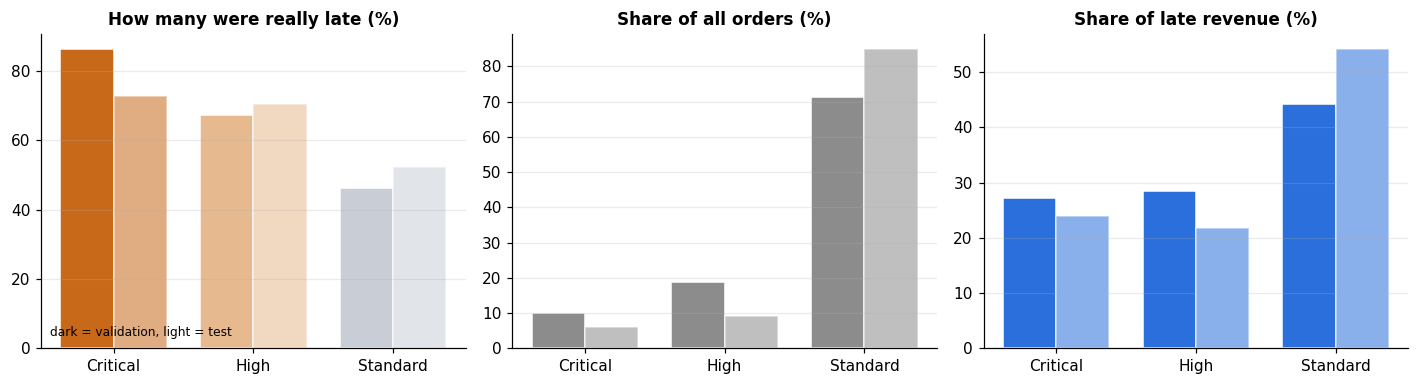

In [15]:
q_crit, q_high = np.quantile(pr_va, [0.90, 0.70])
def tier(p, S):
    pr = p*S
    t = np.where(pr >= q_crit, '1 Critical', np.where(pr >= q_high, '2 High', '3 Standard'))
    return np.where((p < THRESHOLD) & (t != '1 Critical'), '3 Standard', t)

def tier_table(raw, p, y):
    S = raw['Sales'].values; t = tier(p, S)
    g = pd.DataFrame({'tier':t,'late':y,'Sales':S}).assign(late_value=lambda d: d.late*d.Sales).groupby('tier').agg(
        orders=('late','size'), late_rate=('late','mean'), avg_sales=('Sales','mean'), late_value=('late_value','sum'))
    g['share_of_orders'] = g.orders/g.orders.sum(); g['share_of_late_revenue'] = g.late_value/g.late_value.sum(); return g
tt_va, tt_te = tier_table(raw_va,p_va,y_va), tier_table(raw_te,p_te,y_te)
show_cols = {'orders':'Orders','late_rate':'Share really late','avg_sales':'Average order value','share_of_orders':'Share of all orders','share_of_late_revenue':'Share of late revenue'}
print('Validation'); display(tt_va[list(show_cols)].rename(columns=show_cols).round(2))
print('Test'); display(tt_te[list(show_cols)].rename(columns=show_cols).round(2))

TC = {'1 Critical':'#c8691a', '2 High':'#e7b98f', '3 Standard':'#c9ced6'}
fig, axs = plt.subplots(1,3, figsize=(13,3.6))
for j,(nm,tt,al) in enumerate((('Validation',tt_va,1.0),('Test',tt_te,0.55))):
    axs[0].bar(np.arange(3)+(j-0.5)*0.38, tt.late_rate*100, 0.38, color=[TC[i] for i in tt.index], alpha=al, edgecolor='white')
    axs[1].bar(np.arange(3)+(j-0.5)*0.38, tt.share_of_orders*100, 0.38, color='#8c8c8c', alpha=al, edgecolor='white')
    axs[2].bar(np.arange(3)+(j-0.5)*0.38, tt.share_of_late_revenue*100, 0.38, color='#2a6fdb', alpha=al, edgecolor='white')
for ax,t in zip(axs, ['How many were really late (%)','Share of all orders (%)','Share of late revenue (%)']):
    ax.set_xticks(range(3)); ax.set_xticklabels(['Critical','High','Standard']); ax.set_title(t); ax.grid(axis='x', alpha=0)
axs[0].text(0.02, 0.04, 'dark = validation, light = test', transform=axs[0].transAxes, fontsize=8)
plt.tight_layout(); plt.show()

### What the queue will look like in the app
The ten highest priority orders in the test set. The last column shows what really happened. The app will not know this at order time.

In [16]:
q = raw_te[['Order Id','Shipping Mode','Order Region','Sales']].copy()
q['Chance late'] = p_te.round(2); q['Priority'] = (p_te*raw_te.Sales.values).round(0); q['Tier'] = tier(p_te, raw_te.Sales.values)
q['Really late?'] = np.where(y_te==1, 'yes', 'no')
display(q.sort_values('Priority', ascending=False).head(10).reset_index(drop=True))

,Order Id,Shipping Mode,Order Region,Sales,Chance late,Priority,Tier,Really late?
0,68736,First Class,Northern Europe,2259.949997,1.00,2260.0,1 Critical,yes
1,68883,First Class,Western Europe,2149.989990,1.00,2150.0,1 Critical,yes
2,68703,Standard Class,Northern Europe,3449.909988,0.59,2045.0,1 Critical,no
3,68724,Standard Class,Western Europe,2859.890003,0.66,1885.0,1 Critical,yes
4,68858,Standard Class,Southern Europe,2839.910003,0.62,1772.0,1 Critical,no
5,68809,Standard Class,Southern Europe,2779.860000,0.60,1655.0,1 Critical,yes
6,68345,Same Day,Northern Europe,1629.890030,1.00,1630.0,1 Critical,yes
7,65909,First Class,Western Europe,1589.870018,1.00,1590.0,1 Critical,yes
8,68316,First Class,Western Europe,1529.900009,1.00,1530.0,1 Critical,yes
9,68569,First Class,Western Europe,1529.900009,1.00,1530.0,1 Critical,yes


## 8. Save the settings for the app
The app will read these settings from a file. We also save a corrected file of real Sales values, because the old file held scaled numbers by mistake.

In [17]:
config = {
  'formula': 'priority = p_late ** alpha * Sales',
  'alpha': 1.0,
  'risk_threshold': THRESHOLD,
  'tier_cutoffs_priority_score': {'critical_min': float(q_crit), 'high_min': float(q_high)},
  'tiers_defined_on': 'validation priority score: top 10 percent Critical, next 20 percent High',
  'value_column': 'Sales (order level, real currency)',
  'default_review_budgets': list(KS),
}
json.dump(config, open(DATA/'priority_config.json','w'), indent=2); print('saved priority_config.json'); print(json.dumps(config, indent=2))

fixed = pd.concat([raw_tr.assign(split='train'), raw_va.assign(split='val'), raw_te.assign(split='test')])[['split','Order Id','Sales']]
fixed.to_csv(DATA/'priority_value_sales.csv', index=False)
print('saved priority_value_sales.csv with real Sales values:', fixed.shape)

saved priority_config.json
{
  "formula": "priority = p_late ** alpha * Sales",
  "alpha": 1.0,
  "risk_threshold": 0.38,
  "tier_cutoffs_priority_score": {
    "critical_min": 707.5980169246834,
    "high_min": 407.10172694931333
  },
  "tiers_defined_on": "validation priority score: top 10 percent Critical, next 20 percent High",
  "value_column": "Sales (order level, real currency)",
  "default_review_budgets": [
    0.05,
    0.1,
    0.2,
    0.3
  ]
}
saved priority_value_sales.csv with real Sales values: (65752, 3)


## Summary in plain words

**What we built:** a score for every order: chance of being late × Sales. Orders with the highest score are handled first.

**What we learned**

1. **The chances are honest.** When the model says 80%, about 80% of those orders are really late. The only weak group is the lowest risk one, which is late more often than the model says.
2. **Using both risk and money works best.** Risk only fills the queue with cheap orders. Sales only picks big orders that are often not late. Together they reach the most late revenue.
3. **We reach about three quarters of the best possible result.** The perfect oracle reaches 35% of late revenue in the top 10% (validation). Heads Up reaches 27%.
4. **A simple rule ties the model for ordering the queue.** Both reach about 27% (validation) and 36% (test). We state this openly. The model still gives a chance for each order and SHAP explains it.
5. **Balanced is the best setting.** Giving more weight to risk cleans the queue but reaches less money.
6. **Order values dropped in the test period.** The average order was about 600 before and 401 in the test period. In real use the tier cut points must be updated with recent data.
7. **The tiers work.** In validation, Critical orders were 86% late and held 27% of all late revenue with only 10% of the orders.

**Decision for the app:** rank by chance × Sales, flag orders with chance 0.38 or higher, show the three tiers, and explain each flagged order with SHAP.

